We will use kmeans clustering to figure out the species of the penguins

In [1]:
# standard packaging

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={'figure.figsize':(10,8)})



In [5]:
# load the dataset from GitHub - original source

dataset = pd.read_csv("C:\\Users\\DD\\Desktop\\IAAC\\DATA encoding\\final project_entropy prediction\\data\\processed\\patch_training_data_full.csv")

Data prep

In [6]:
dataset_clean = dataset.dropna(how = "any")
dataset_clean.info()
dataset_clean.reset_index(inplace=True, drop = True)
dataset_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patch_id               2500 non-null   str    
 1   city_code              2500 non-null   str    
 2   patch_idx              2500 non-null   int64  
 3   centroid_lat           2500 non-null   float64
 4   centroid_lon           2500 non-null   float64
 5   minx_utm               2500 non-null   float64
 6   miny_utm               2500 non-null   float64
 7   maxx_utm               2500 non-null   float64
 8   maxy_utm               2500 non-null   float64
 9   crs_utm                2500 non-null   str    
 10  n_segments             2500 non-null   int64  
 11  n_intersections        2500 non-null   int64  
 12  n_nodes_in_patch       2500 non-null   int64  
 13  n_components           2500 non-null   int64  
 14  n_nodes_largest        2500 non-null   int64  
 15  largest_fractio

,patch_id,city_code,patch_idx,centroid_lat,centroid_lon,minx_utm,miny_utm,maxx_utm,maxy_utm,crs_utm,...,n_nodes_used,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity,distance_to_center_km
0,chicago_0338,chicago,338,41.704967,-87.703029,441108.44,4616858.65,441908.44,4617658.65,EPSG:32616,...,323,109,7,0.603715,0.337461,0.021672,38.81,22082.51,1.006612,20.043
1,chandigarh_0157,chandigarh,157,30.693441,76.818190,673742.34,3396638.99,674542.34,3397438.99,EPSG:32643,...,183,141,5,0.191257,0.770492,0.027322,26.78,7659.62,1.011909,5.766
2,chicago_0085,chicago,85,41.798135,-87.781081,434708.44,4627258.65,435508.44,4628058.65,EPSG:32616,...,253,72,0,0.683794,0.284585,0.000000,41.82,19322.01,1.005433,15.597
3,chicago_0637,chicago,637,41.755742,-87.645845,445908.44,4622458.65,446708.44,4623258.65,EPSG:32616,...,411,115,8,0.661800,0.279805,0.019465,40.53,30157.71,1.013679,13.427
4,chicago_0582,chicago,582,41.726867,-87.655175,445108.44,4619258.65,445908.44,4620058.65,EPSG:32616,...,381,111,3,0.679790,0.291339,0.007874,41.05,28486.59,1.001442,16.712


Encode the variables

In [14]:
#encoding categorical variables
y = dataset_clean["entropy_normalised"]
dataset_x = dataset_clean.iloc[:,1:]
X = dataset_clean.drop(columns=[
    "patch_id", "city_code", "entropy_normalised",
    "patch_idx", "centroid_lat", "centroid_lon",
    "minx_utm", "miny_utm", "maxx_utm", "maxy_utm", "crs_utm",
    "n_segments", "n_intersections", "n_nodes_in_patch",
    "n_components", "n_nodes_largest", "largest_fraction",
    "entropy_raw", "entropy_weighted_raw", "entropy_weighted_norm", "phi",
    "n_edges_used",
], errors='ignore')

X.head()

,n_nodes_used,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity,distance_to_center_km
0,323,109,7,0.603715,0.337461,0.021672,38.81,22082.51,1.006612,20.043
1,183,141,5,0.191257,0.770492,0.027322,26.78,7659.62,1.011909,5.766
2,253,72,0,0.683794,0.284585,0.000000,41.82,19322.01,1.005433,15.597
3,411,115,8,0.661800,0.279805,0.019465,40.53,30157.71,1.013679,13.427
4,381,111,3,0.679790,0.291339,0.007874,41.05,28486.59,1.001442,16.712


Training attempt

In [15]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
# Using the predict method of KMeans to predict 3 clusters using the sample data

labels = model.predict(X)

In [21]:
# We plot a cross tab matrix to check how well has our K-Means model classified the Species

matrix = pd.DataFrame({'labels': labels, 'entropy': y})
print(matrix.groupby('labels')['entropy'].agg(['mean', 'min', 'max', 'count']).round(3))



         mean    min    max  count
labels                            
0       0.728  0.384  0.993   1140
1       0.579  0.390  0.987    488
2       0.709  0.386  0.992    872


Now standard scaling ?


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
X_scaled = scaler.fit_transform(X)

In [24]:
#Train another model
model_2 = KMeans(n_clusters=3)
model_2.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [25]:
labels_ss = model_2.predict(X_scaled)

In [27]:
#plotting the Cross-tab matrix with the new labels

matrix_new = pd.DataFrame({'labels': labels_ss, 'entropy': y})
print(matrix_new.groupby('labels')['entropy'].agg(['mean', 'min', 'max', 'count']).round(3))


         mean    min    max  count
labels                            
0       0.775  0.451  0.992    522
1       0.724  0.384  0.993   1514
2       0.494  0.390  0.971    464


In [28]:
dataset_clean["kmeansLabels"] = labels_ss

See where the problem is

Text(0.5, 1.0, 'K-Means clusters')

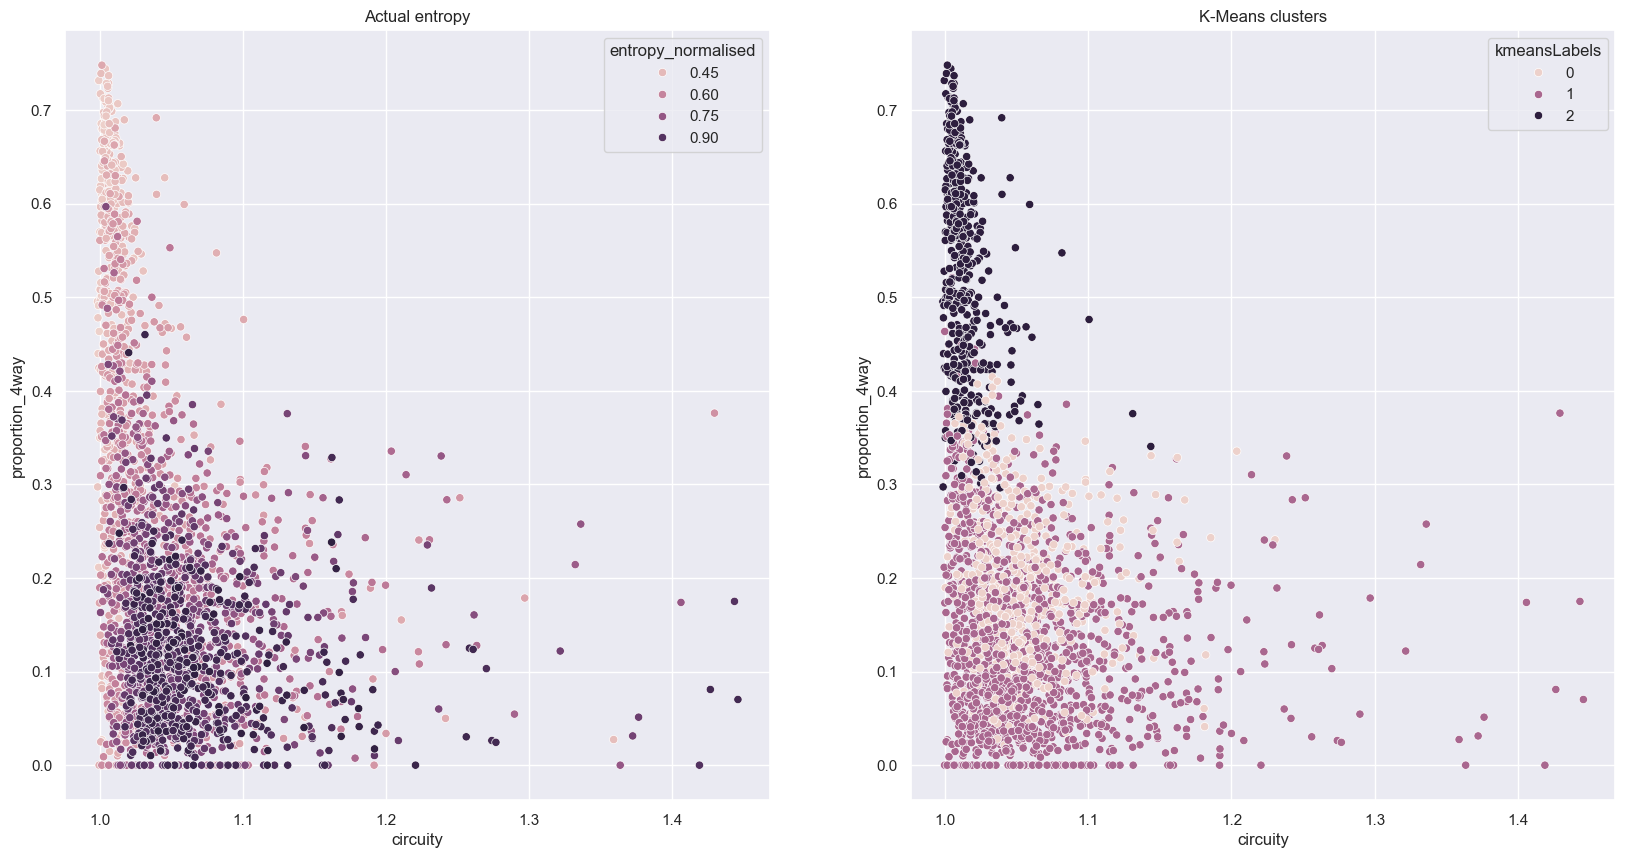

In [29]:
#create two plots side by side

dataset_clean["kmeansLabels"] = labels_ss

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 10))
sns.scatterplot(x="circuity", y="proportion_4way", data=dataset_clean, hue="entropy_normalised", ax=ax1)
sns.scatterplot(x="circuity", y="proportion_4way", data=dataset_clean, hue="kmeansLabels", ax=ax2)

ax1.set_title("Actual entropy")
ax2.set_title("K-Means clusters")


Text(0.5, 1.0, 'K-Means clusters')

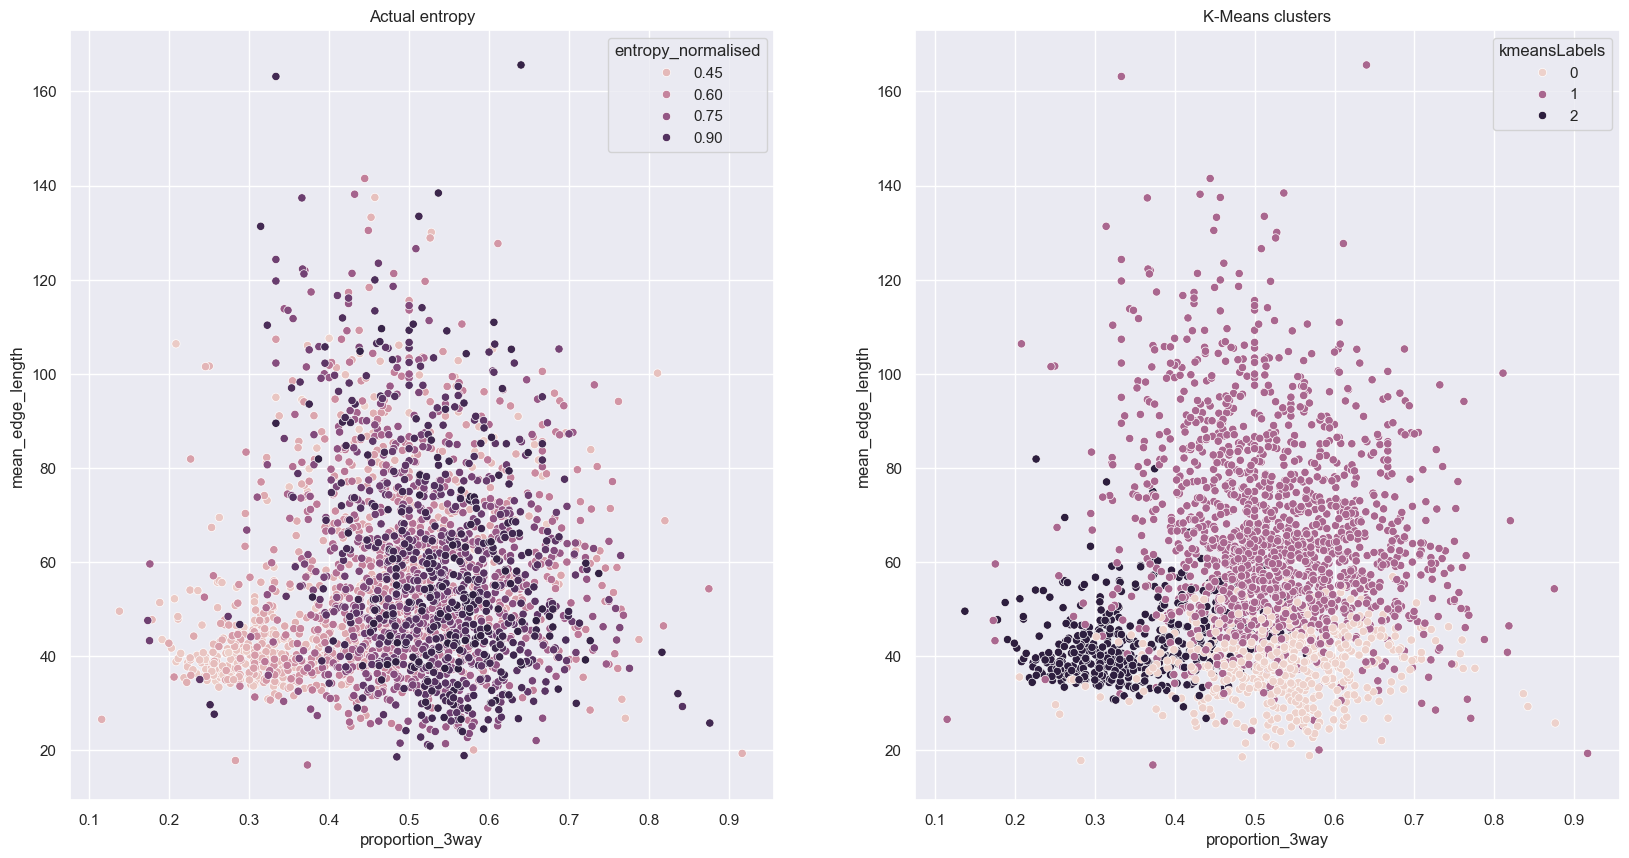

In [32]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 10))
sns.scatterplot(x="proportion_3way", y="mean_edge_length", data=dataset_clean, hue="entropy_normalised", ax=ax1)
sns.scatterplot(x="proportion_3way", y="mean_edge_length", data=dataset_clean, hue="kmeansLabels", ax=ax2)

ax1.set_title("Actual entropy")
ax2.set_title("K-Means clusters")



# now with only 2 variables

In [17]:
import numpy as np
X_scaled_select = X_scaled[:, [0, 2]]

In [18]:
#Train another model
model_3 = KMeans(n_clusters=3)
model_3.fit(X_scaled_select)
labels_select = model_3.predict(X_scaled_select)

In [19]:
#plotting the Cross-tab matrix with the new labels

matrix_new = pd.DataFrame({'labels': labels_select, 'species': y})
ct_new = pd.crosstab(matrix_new['labels'], matrix_new['species'])
print(ct_new)

species  Adelie  Chinstrap  Gentoo
labels                            
0             1          4     119
1           141          5       0
2             4         59       1


In [20]:
penguins_clean["kmeansLabels"] = labels_select

/tmp/ipykernel_11579/1071958234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_clean["kmeansLabels"] = labels_select


<Axes: xlabel='culmen_length_mm', ylabel='flipper_length_mm'>

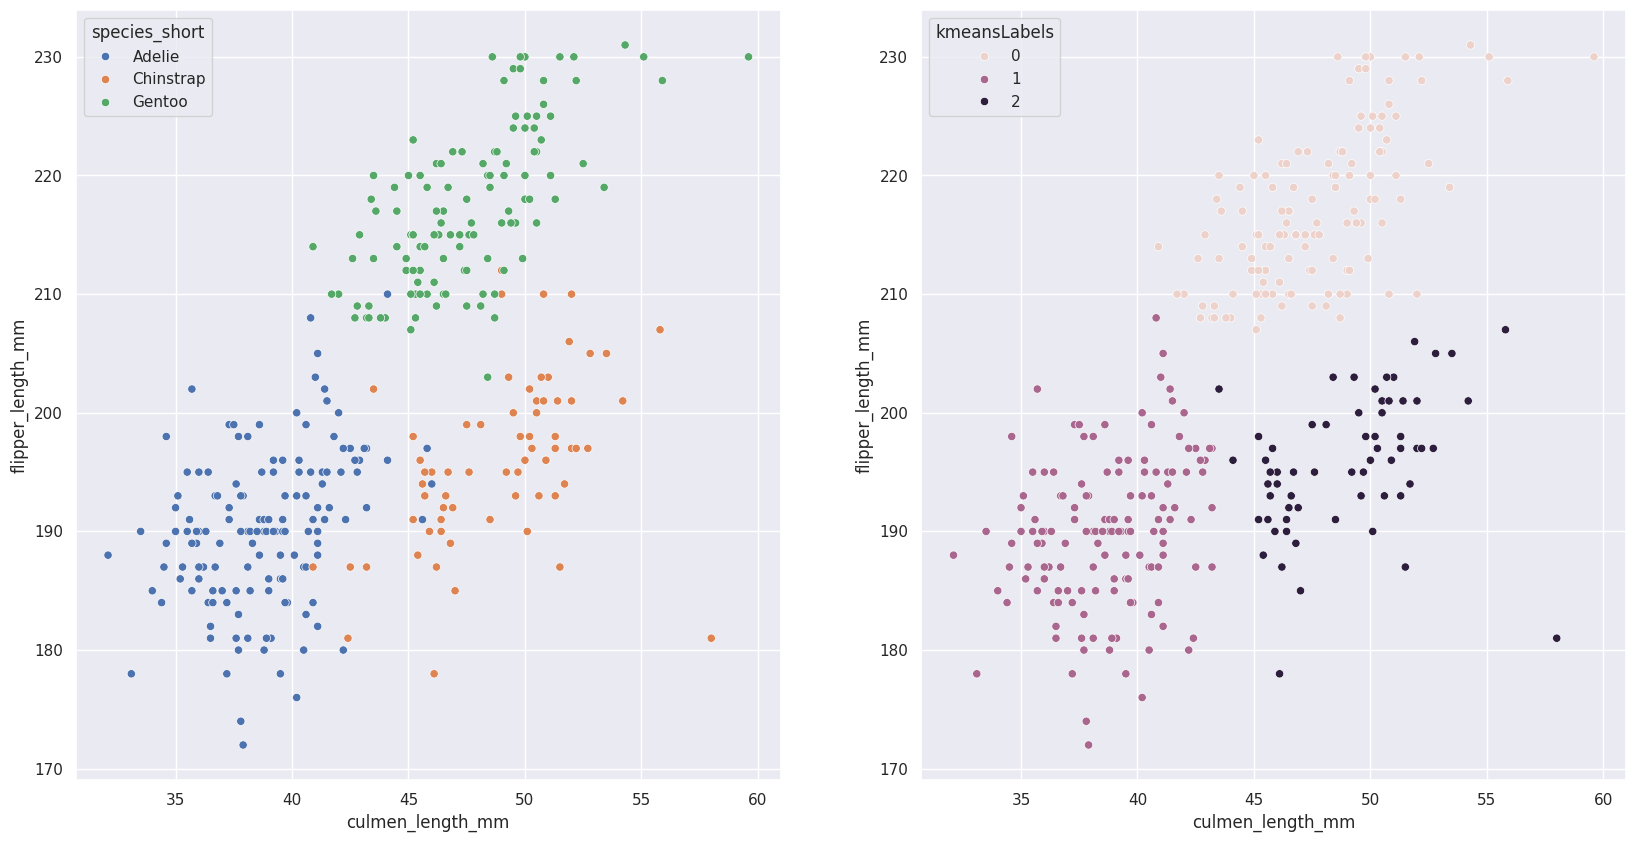

In [21]:
#create two plots side by side

fig, (ax1, ax2) = plt.subplots(ncols=2,  figsize = (20,10))
sns.scatterplot(x="culmen_length_mm", y="flipper_length_mm", data = penguins_clean, hue = "species_short", ax=ax1)
sns.scatterplot(x="culmen_length_mm", y="flipper_length_mm", data = penguins_clean, hue = "kmeansLabels", ax=ax2)